In [12]:
%load_ext autoreload
%autoreload 2

Failed to reload module 'building.scaling_experiment' from file '/home/nathan/Documents/multi-chirp/building/scaling_experiment.py'
Traceback (most recent call last):
  File "/home/nathan/Documents/multi-chirp/.venv/lib/python3.11/site-packages/IPython/extensions/autoreload.py", line 325, in check
    superreload(m, reload, self.old_objects)
  File "/home/nathan/Documents/multi-chirp/.venv/lib/python3.11/site-packages/IPython/extensions/autoreload.py", line 625, in superreload
    update_generic(old_obj, new_obj)
  File "/home/nathan/Documents/multi-chirp/.venv/lib/python3.11/site-packages/IPython/extensions/autoreload.py", line 451, in update_generic
    update(a, b)
  File "/home/nathan/Documents/multi-chirp/.venv/lib/python3.11/site-packages/IPython/extensions/autoreload.py", line 403, in update_class
    if update_generic(old_obj, new_obj):
       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/nathan/Documents/multi-chirp/.venv/lib/python3.11/site-packages/IPython/extensions/autore

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


[autoreload of building.scaling_experiment failed: Traceback (most recent call last):
  File "/home/nathan/Documents/multi-chirp/.venv/lib/python3.11/site-packages/IPython/extensions/autoreload.py", line 325, in check
    superreload(m, reload, self.old_objects)
  File "/home/nathan/Documents/multi-chirp/.venv/lib/python3.11/site-packages/IPython/extensions/autoreload.py", line 625, in superreload
    update_generic(old_obj, new_obj)
  File "/home/nathan/Documents/multi-chirp/.venv/lib/python3.11/site-packages/IPython/extensions/autoreload.py", line 451, in update_generic
    update(a, b)
  File "/home/nathan/Documents/multi-chirp/.venv/lib/python3.11/site-packages/IPython/extensions/autoreload.py", line 403, in update_class
    if update_generic(old_obj, new_obj):
       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/nathan/Documents/multi-chirp/.venv/lib/python3.11/site-packages/IPython/extensions/autoreload.py", line 451, in update_generic
    update(a, b)
  File "/home/nathan/Docum

In [13]:
from pathlib import Path
import os
import sys

import pyrootutils

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
os.environ.setdefault("TF_ENABLE_ONEDNN_OPTS", "0")
os.environ.setdefault("TF_XLA_FLAGS", "--tf_xla_auto_jit=0")
os.environ.setdefault("TF_GPU_ALLOCATOR", "cuda_malloc_async")

ROOT = pyrootutils.setup_root(
    search_from=Path.cwd(),
    indicator="pyproject.toml",
    pythonpath=True,
    dotenv=True,
)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))


In [14]:
from building.scaling_experiment import (
    ScalingRunConfig,
    load_full_arrays,
    run_experiments,
    summarize_results,
    plot_summary,
)

In [15]:
COLLECTION = "diff_species"
N_SAMPLES = 10
EPOCHS = 10
PATIENCE = 3
BATCH_SIZE = 32
SEED = 42
THRESHOLD = 0.5
BUILD_MODEL = "cnn1d"
MODELS_DIR = ROOT / "models" / "scaling"
RESULTS_FILE = MODELS_DIR / "results.jsonl"

In [ ]:
config = ScalingRunConfig(
    collection=COLLECTION,
    build_model=BUILD_MODEL,
    epochs=EPOCHS,
    patience=PATIENCE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    threshold=THRESHOLD,
    models_dir=MODELS_DIR,
    results_file=RESULTS_FILE,
)

arrays = load_full_arrays(
    collection=COLLECTION,
    batch_size=BATCH_SIZE,
    seed=SEED,
)

print(f"Loaded {len(arrays.class_names)} classes:")
print(arrays.class_names)

Found 42552 files belonging to 10 classes.
Found 10456 files belonging to 10 classes.
Found 10468 files belonging to 10 classes.


In [ ]:
baseline_rows = run_experiments(arrays, config, run_baseline=True, run_scaling=False)
print(f"New baseline runs: {len(baseline_rows)}")
if baseline_rows:
    print("Last baseline row:")
    print(baseline_rows[-1])

[baseline] target=Phylloscopus_xanthoschistos
[baseline data] target=1400 non_target=1400 non_target_ratio=0.50
Epoch 1/10


I0000 00:00:1775549569.644672   84464 service.cc:145] XLA service 0x72446c004590 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775549569.644704   84464 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
I0000 00:00:1775549575.077111   84464 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


88/88 - 15s - 165ms/step - accuracy: 0.5589 - loss: 0.6911 - precision: 0.5390 - recall: 0.8143 - val_accuracy: 0.6400 - val_loss: 0.6874 - val_precision: 0.6842 - val_recall: 0.5200
Epoch 2/10
88/88 - 4s - 47ms/step - accuracy: 0.6736 - loss: 0.6781 - precision: 0.6493 - recall: 0.7550 - val_accuracy: 0.6883 - val_loss: 0.6638 - val_precision: 0.6647 - val_recall: 0.7600
Epoch 3/10
88/88 - 4s - 47ms/step - accuracy: 0.6796 - loss: 0.6458 - precision: 0.6710 - recall: 0.7050 - val_accuracy: 0.6600 - val_loss: 0.6304 - val_precision: 0.7105 - val_recall: 0.5400
Epoch 4/10
88/88 - 4s - 47ms/step - accuracy: 0.6800 - loss: 0.6133 - precision: 0.6845 - recall: 0.6679 - val_accuracy: 0.6817 - val_loss: 0.6000 - val_precision: 0.7088 - val_recall: 0.6167
Epoch 5/10
88/88 - 4s - 48ms/step - accuracy: 0.6996 - loss: 0.5889 - precision: 0.7024 - recall: 0.6929 - val_accuracy: 0.6867 - val_loss: 0.5852 - val_precision: 0.7276 - val_recall: 0.5967
Epoch 6/10
88/88 - 4s - 47ms/step - accuracy: 0.7

In [ ]:
import pandas as pd

def print_per_class_baseline_results(arrays, results_file):
    try:
        df = pd.read_json(results_file, lines=True)
    except Exception as e:
        print(f"Could not read results file: {e}")
        return

    if "run_type" not in df.columns:
        print("No run_type column found in results file.")
        return

    baseline_df = df[df["run_type"] == "baseline"].copy()
    if baseline_df.empty:
        print("No baseline rows found.")
        return

    if "target_class" not in baseline_df.columns:
        print("No target_class column found in baseline rows.")
        return

    class_names = list(arrays.class_names)
    for cls in class_names:
        print(f"\nResults for class: '{cls}'")
        matches = baseline_df[baseline_df["target_class"] == cls]
        if matches.empty:
            print("  No baseline results found for this species.")
            continue

        row = matches.iloc[-1]
        prec = row.get("precision")
        rec = row.get("recall")
        epochs = row.get("epochs_trained")
        timestamp = row.get("timestamp")

        print(f"  Precision: {prec:.4f}" if pd.notna(prec) else "  Precision: N/A")
        print(f"  Recall:    {rec:.4f}" if pd.notna(rec) else "  Recall: N/A")
        print(f"  Epochs:    {int(epochs)}" if pd.notna(epochs) else "  Epochs: N/A")
        print(f"  Timestamp: {timestamp}" if pd.notna(timestamp) else "  Timestamp: N/A")

print_per_class_baseline_results(arrays, RESULTS_FILE)


Results for class: 'Phylloscopus_bonelli'
  Precision: 0.5806
  Recall:    0.8225
  Epochs:    10
  Timestamp: 2026-04-07 07:56:32.989761+00:00

Results for class: 'Phylloscopus_collybita'
  Precision: 0.6450
  Recall:    0.4955
  Epochs:    10
  Timestamp: 2026-04-07 07:57:19.590757+00:00

Results for class: 'Phylloscopus_fuscatus'
  Precision: 0.7143
  Recall:    0.9239
  Epochs:    10
  Timestamp: 2026-04-07 07:57:37.093992+00:00

Results for class: 'Phylloscopus_humei'
  Precision: 0.5708
  Recall:    0.7611
  Epochs:    10
  Timestamp: 2026-04-07 07:58:10.511784+00:00

Results for class: 'Phylloscopus_ibericus'
  Precision: 0.6016
  Recall:    0.8261
  Epochs:    10
  Timestamp: 2026-04-07 07:58:57.119654+00:00

Results for class: 'Phylloscopus_inornatus'
  Precision: 0.7931
  Recall:    0.5066
  Epochs:    10
  Timestamp: 2026-04-07 07:59:39.221493+00:00

Results for class: 'Phylloscopus_sibilatrix'
  Precision: 0.6625
  Recall:    0.7000
  Epochs:    10
  Timestamp: 2026-04-07 

In [ ]:
scaling_rows = run_experiments(
    arrays=arrays,
    config=config,
    n_samples=N_SAMPLES,
    k_values=range(2, len(arrays.class_names)),
    run_baseline=False,
    run_scaling=True,
)
print(f"New scaling runs: {len(scaling_rows)}")
if scaling_rows:
    print("Last scaling row:")
    print(scaling_rows[-1])

[scaling] k=2 sample=1/10
[scaling data] chosen_each=1283 target_total=2566 non_target=1283 non_target_ratio=0.33 match_rule=True
Epoch 1/10
121/121 - 11s - 93ms/step - accuracy: 0.3531 - loss: 0.6525 - precision: 0.4103 - recall: 0.0042 - val_accuracy: 0.3851 - val_loss: 0.6353 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/10
121/121 - 6s - 47ms/step - accuracy: 0.3718 - loss: 0.6329 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.4000 - val_loss: 0.6294 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/10
121/121 - 6s - 47ms/step - accuracy: 0.4336 - loss: 0.6205 - precision: 0.8442 - recall: 0.0169 - val_accuracy: 0.4103 - val_loss: 0.6166 - val_precision: 0.6951 - val_recall: 0.0651
Epoch 4/10
121/121 - 6s - 47ms/step - accuracy: 0.4435 - loss: 0.6062 - precision: 0.6667 - recall: 0.0764 - val_accuracy: 0.4103 - val_loss: 0.6105 - val_precision: 0.6897 - val_recall: 0.0686
Epoch 5/10
121/121 - 6s - 46ms/step - accuracy: 0.4518 - loss: 0.5991

In [ ]:
baseline_metrics, summary_df = summarize_results(RESULTS_FILE)
print(f"Baseline recall: {baseline_metrics['recall']:.4f}")
print(f"Baseline precision: {baseline_metrics['precision']:.4f}")
summary_df

Baseline mean recall: 0.7020


,k,mean,std
0,2,0.143612,0.096610
1,3,0.064044,0.091065
2,4,0.062787,0.084254
3,5,0.049563,0.049466
4,6,0.044540,0.064377


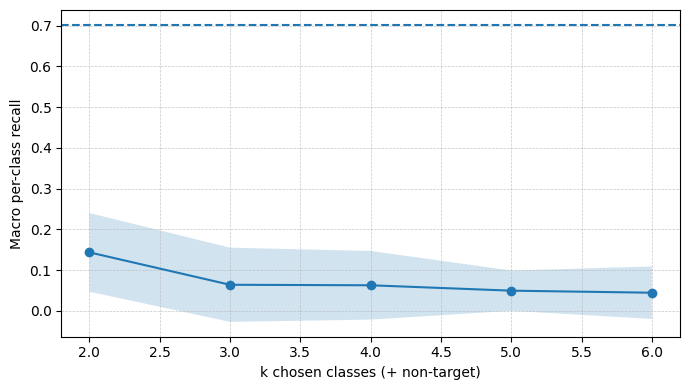

In [ ]:
plot_summary(summary_df, baseline=baseline_metrics)